# Main V10 — Low-Patient-ID Feature Subsets

**Hypothesis.** The Patient Identifiability analysis (`Analysis_Identifiability.ipynb`)
showed that GC-derived feature representations vary widely in how strongly they encode
patient identity:

| Feature subset            | Patient-ID accuracy | Tested for seizure prediction? |
|---------------------------|--------------------:|:------------------------------:|
| Raw GC flat (324d)        | 99.1% (V3, V5b)     | ✅                              |
| All engineered (67d)      | 85.4% (V4)          | ✅                              |
| In-degree only (18d)      | 71.7%               | ❌                              |
| Out-degree only (18d)     | 66.4%               | ❌                              |
| **Net-flow only (18d)**   | **36.7%**           | ❌                              |
| Off-diag mean only (1d)   | 11.3%               | ❌                              |

If patient-specific structure is the dominant LOPO confound (as RQ2 claims),
then training a seizure predictor on a *low-PID* representation should improve
cross-patient generalization — even at the cost of throwing away most GC
information. V10 tests this directly using **Net-flow (18d)** and
**Off-diag mean (1d)** as the feature representations.

Pipeline mirrors V4: same VAR(5) GC cache, same per-patient interictal cap,
same evaluate_fold(), LOPO with LR/SVM (the V4 winners on engineered features).


## 0 · Setup & imports

In [1]:
# --- portable repo bootstrap (added for public release; locates the repo root) ---
import sys as _sys, pathlib as _pl
REPO = _pl.Path.cwd()
while not (REPO / 'src' / 'config.py').exists() and REPO != REPO.parent:
    REPO = REPO.parent
_sys.path.insert(0, str(REPO / 'src'))
from pathlib import Path
CODE_DIR = str(REPO); CODE = REPO; CODEV2 = REPO; PROJECT_DIR = REPO
# --------------------------------------------------------------------------------

# Cell 0 — Imports & config (mirrors V4)
import os, sys, json, warnings, time
from pathlib import Path
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import wilcoxon

# [path set by bootstrap] CODE_DIR = r"<repo>/Code"
sys.path.insert(0, CODE_DIR)

from config import (
    DATA_ROOT, CANONICAL_CHANNELS, N_CHANNELS, FS,
    WINDOW_SEC, STEP_SEC, PREICTAL_SEC, SPH_SEC, POSTICTAL_EXCL_SEC,
    EXCLUDED_PATIENTS, GC_MATRICES_DIR_V3, RESULTS_DIR,
    INTERICTAL_MULTIPLIER, MAX_INTERICTAL_ABS, RANDOM_SEED,
)
from summary_parser import parse_all_summaries

from sklearn.linear_model    import LogisticRegression
from sklearn.svm             import SVC
from sklearn.preprocessing   import StandardScaler
from sklearn.pipeline        import Pipeline
from sklearn.model_selection import GroupKFold, GridSearchCV
from sklearn.metrics         import (roc_auc_score, average_precision_score,
                                     precision_recall_curve, roc_curve)

np.random.seed(RANDOM_SEED)
os.makedirs(RESULTS_DIR, exist_ok=True)

print(f"Code dir       : {CODE_DIR}")
print(f"GC cache       : {GC_MATRICES_DIR_V3}")
print(f"Interictal cap : {INTERICTAL_MULTIPLIER}x preictal (hard ceil={MAX_INTERICTAL_ABS})")
print('V10 ready.')


Code dir       : <repo>/Code
GC cache       : cache_gc_var5
Interictal cap : 5x preictal (hard ceil=5000)
V10 ready.


## 1 · Load GC matrices from V3 cache

In [2]:
# Cell 1 — Parse summaries
all_seizures = parse_all_summaries(DATA_ROOT)
print(f'Patients with seizures: {sum(1 for v in all_seizures.values() if v)}')


[INFO] chb01: 7 seizure-containing files, 7 total seizures
[INFO] chb02: 3 seizure-containing files, 3 total seizures
[INFO] chb03: 7 seizure-containing files, 7 total seizures
[INFO] chb04: 3 seizure-containing files, 4 total seizures
[INFO] chb05: 5 seizure-containing files, 5 total seizures
[INFO] chb06: 7 seizure-containing files, 10 total seizures
[INFO] chb07: 3 seizure-containing files, 3 total seizures
[INFO] chb08: 5 seizure-containing files, 5 total seizures
[INFO] chb09: 3 seizure-containing files, 4 total seizures
[INFO] chb10: 7 seizure-containing files, 7 total seizures
[INFO] chb11: 3 seizure-containing files, 3 total seizures
[INFO] chb12: 13 seizure-containing files, 40 total seizures
[INFO] chb13: 8 seizure-containing files, 12 total seizures
[INFO] chb14: 7 seizure-containing files, 8 total seizures
[INFO] chb15: 14 seizure-containing files, 20 total seizures
[INFO] chb16: 6 seizure-containing files, 10 total seizures
[INFO] chb17: 3 seizure-containing files, 3 total

In [3]:
# Cell 2 — Load V3 cache (identical to V4 loader)
cache_root = Path(GC_MATRICES_DIR_V3)
assert cache_root.exists(), f"V3 cache missing at {cache_root.resolve()}"

patients_all = sorted([
    p for p in os.listdir(DATA_ROOT)
    if os.path.isdir(os.path.join(DATA_ROOT, p))
    and p.startswith('chb')
    and p not in EXCLUDED_PATIENTS
])

patient_data = {}
for pid in patients_all:
    pdir = cache_root / pid
    if not pdir.exists():
        continue
    gc_files = sorted(pdir.glob('*_gc.npy'))
    if not gc_files:
        continue
    gc_list, lb_list = [], []
    for gp in gc_files:
        lp = gp.with_name(gp.name.replace('_gc.npy', '_labels.npy'))
        if not lp.exists():
            continue
        gc_list.append(np.load(gp))
        lb_list.append(np.load(lp))
    if not gc_list:
        continue
    X = np.concatenate(gc_list, axis=0).astype(np.float32)
    y = np.concatenate(lb_list, axis=0).astype(np.int8)
    n_pre = int((y == 1).sum())
    n_int = int((y == 0).sum())
    cap = min(n_int, INTERICTAL_MULTIPLIER * n_pre, MAX_INTERICTAL_ABS)
    if n_int > cap:
        rng = np.random.default_rng(RANDOM_SEED + hash(pid) % 10_000)
        int_idx = np.where(y == 0)[0]
        keep_int = rng.choice(int_idx, size=cap, replace=False)
        pre_idx = np.where(y == 1)[0]
        keep = np.sort(np.concatenate([pre_idx, keep_int]))
        X, y = X[keep], y[keep]
    if n_pre == 0:
        continue
    patient_data[pid] = (X, y)
    print(f'  {pid}: pre={int((y==1).sum())}  int={int((y==0).sum())}')

patient_ids = sorted(patient_data.keys())
print(f'\nLoaded {len(patient_ids)} patients.')


  chb01: pre=296  int=1480
  chb02: pre=296  int=1480
  chb03: pre=444  int=2220
  chb04: pre=296  int=1480
  chb05: pre=444  int=2220
  chb06: pre=1037  int=5000
  chb07: pre=445  int=2225
  chb08: pre=741  int=3705
  chb09: pre=592  int=2960
  chb10: pre=888  int=4440
  chb13: pre=444  int=2220
  chb14: pre=774  int=3870
  chb15: pre=320  int=1600
  chb16: pre=347  int=1735
  chb17: pre=444  int=2220
  chb18: pre=592  int=2960
  chb19: pre=296  int=1480
  chb20: pre=369  int=1845
  chb22: pre=296  int=1480
  chb23: pre=608  int=3040
  chb24: pre=939  int=4327

Loaded 21 patients.


## 2 · Low-PID feature extraction

Two feature representations are extracted from each 18x18 GC matrix:

**Representation A — Net-flow (18d, PID=36.7%).** Per-channel net directed flow
`net_flow[i] = out_degree[i] - in_degree[i]`. Captures whether a channel is a
net source or sink of directed influence.

**Representation B — Off-diag mean (1d, PID=11.3%).** A single scalar — the
mean of all off-diagonal entries. Extreme dimensional collapse; tests whether
*any* preictal signal survives at near-chance patient identifiability.


In [4]:
# Cell 3 — Feature extraction

def extract_netflow(A: np.ndarray) -> np.ndarray:
    in_deg  = A.sum(axis=1) - np.diag(A)
    out_deg = A.sum(axis=0) - np.diag(A)
    return (out_deg - in_deg).astype(np.float32)

def extract_offdiag_mean(A: np.ndarray) -> np.ndarray:
    n = A.shape[0]
    off = ~np.eye(n, dtype=bool)
    return np.array([A[off].mean()], dtype=np.float32)

REPRESENTATIONS = {
    'netflow':      ('Net-flow (18d)',     extract_netflow),
    'offdiag_mean': ('Off-diag mean (1d)', extract_offdiag_mean),
}

feat_data = {key: {} for key in REPRESENTATIONS}
t0 = time.time()
for pid in patient_ids:
    X_gc, y = patient_data[pid]
    for key, (_, fn) in REPRESENTATIONS.items():
        X_f = np.stack([fn(A) for A in X_gc])
        feat_data[key][pid] = (X_f, y)

print(f'Feature extraction done in {time.time()-t0:.1f}s')
for key, (label, _) in REPRESENTATIONS.items():
    pid0 = patient_ids[0]
    print(f'  {label:25s}  shape={feat_data[key][pid0][0].shape}')


Feature extraction done in 0.6s
  Net-flow (18d)             shape=(1776, 18)
  Off-diag mean (1d)         shape=(1776, 1)


## 3 · LOPO machinery

Mirrors V4 evaluate_fold (Youden-J threshold for sens/spec reporting). Same
hyperparameter grids as V4 for LR and SVM.


In [5]:
# Cell 4 — LOPO helpers

def make_lr():
    return ('LR', Pipeline([
        ('scl', StandardScaler()),
        ('clf', LogisticRegression(max_iter=400, solver='lbfgs',
                                   class_weight='balanced',
                                   random_state=RANDOM_SEED))
    ]),
    {'clf__C': [0.01, 0.1, 1.0, 10.0]})

def make_svm():
    return ('SVM', Pipeline([
        ('scl', StandardScaler()),
        ('clf', SVC(kernel='rbf', class_weight='balanced',
                    probability=True, random_state=RANDOM_SEED))
    ]),
    {'clf__C': [0.1, 1.0, 10.0]})

MODEL_FACTORIES = [make_lr, make_svm]

from seizure_metrics import generate_alarms, false_alarms_per_hour
from config import ALARM_K, ALARM_M, ALARM_REFRACTORY, STEP_SEC

def evaluate_fold(probs, y_test, n_interictal_hours):
    if len(np.unique(y_test)) < 2:
        return None
    auc    = roc_auc_score(y_test, probs)
    auc_pr = average_precision_score(y_test, probs)
    fpr, tpr, thr = roc_curve(y_test, probs)
    j_idx  = np.argmax(tpr - fpr)
    thresh = float(thr[j_idx])
    pred   = (probs >= thresh).astype(int)
    tp = int(((pred==1)&(y_test==1)).sum())
    fp = int(((pred==1)&(y_test==0)).sum())
    tn = int(((pred==0)&(y_test==0)).sum())
    fn = int(((pred==0)&(y_test==1)).sum())
    sens = tp / max(tp+fn, 1)
    spec = tn / max(tn+fp, 1)
    prec = tp / max(tp+fp, 1)
    f1   = 2*prec*sens / max(prec+sens, 1e-9)
    bal  = 0.5 * (sens+spec)
    fpr_h = false_alarms_per_hour(generate_alarms(pred.astype(float), 0.5, ALARM_K, ALARM_M, ALARM_REFRACTORY), y_test, STEP_SEC)
    return dict(auc=auc, auc_pr=auc_pr, sensitivity=sens, specificity=spec,
                precision=prec, f1=f1, balanced_accuracy=bal,
                fpr_per_hour=fpr_h, threshold=thresh,
                n_pre=int((y_test==1).sum()), n_int=int((y_test==0).sum()))


def run_lopo(factory, fd, label, max_train=None, tune=True):
    name, _, param_grid = factory()
    print(f'\n== {name} on {label} ({len(patient_ids)} folds) ' + '='*30)
    rows = []
    t0 = time.time()
    for fold_idx, test_pid in enumerate(patient_ids, 1):
        X_tr = np.concatenate([fd[p][0] for p in patient_ids if p != test_pid])
        y_tr = np.concatenate([fd[p][1] for p in patient_ids if p != test_pid])
        groups = np.concatenate([np.full(len(fd[p][1]), i)
                                 for i, p in enumerate(patient_ids) if p != test_pid])
        X_te, y_te = fd[test_pid]
        if max_train is not None and len(X_tr) > max_train:
            rng = np.random.default_rng(RANDOM_SEED + fold_idx)
            idx = rng.choice(len(X_tr), size=max_train, replace=False)
            X_tr, y_tr, groups = X_tr[idx], y_tr[idx], groups[idx]
        _, pipe, grid = factory()
        if tune and grid:
            n_groups = len(np.unique(groups))
            cv = GroupKFold(n_splits=min(3, n_groups))
            search = GridSearchCV(pipe, grid, cv=cv,
                                  scoring='average_precision',
                                  n_jobs=-1, refit=True, verbose=0)
            search.fit(X_tr, y_tr, groups=groups)
            model = search.best_estimator_
            best = search.best_params_
        else:
            pipe.fit(X_tr, y_tr); model = pipe; best = {}
        if hasattr(model.named_steps['clf'], 'predict_proba'):
            probs = model.predict_proba(X_te)[:, 1]
        else:
            probs = model.decision_function(X_te)
            probs = (probs - probs.min()) / (probs.max() - probs.min() + 1e-9)
        hours_int = (y_te == 0).sum() * STEP_SEC / 3600.0
        m = evaluate_fold(probs, y_te, hours_int)
        if m is None:
            continue
        m['patient'] = test_pid
        m['model']   = name
        m['rep']     = label
        rows.append(m)
        print(f'  [{fold_idx:2d}/{len(patient_ids)}] {test_pid}  '
              f'AUC={m["auc"]:.3f}  AUC-PR={m["auc_pr"]:.3f}  '
              f'Sens={m["sensitivity"]:.3f}  Spec={m["specificity"]:.3f}  '
              f'FPR/h={m["fpr_per_hour"]:.1f}')
    print(f'\n  {name} done in {(time.time()-t0)/60:.1f}min')
    return rows

print('LOPO machinery ready.')


LOPO machinery ready.


## 4 · Run LOPO across both representations

In [6]:
# Cell 5 — Run all (representation x model) combos
all_results = {}
for rep_key, (rep_label, _) in REPRESENTATIONS.items():
    for factory in MODEL_FACTORIES:
        name = factory()[0]
        max_train = 20_000 if name == 'SVM' else None
        rows = run_lopo(factory, feat_data[rep_key], rep_label,
                        max_train=max_train, tune=True)
        all_results[(rep_key, name)] = rows
        print(f'  Total rows: {len(rows)}')



== LR on Net-flow (18d) (21 folds) ==============================
  [ 1/21] chb01  AUC=0.335  AUC-PR=0.118  Sens=1.000  Spec=0.003  FPR/h=358.8
  [ 2/21] chb02  AUC=0.545  AUC-PR=0.232  Sens=0.324  Spec=0.844  FPR/h=56.2
  [ 3/21] chb03  AUC=0.636  AUC-PR=0.244  Sens=0.561  Spec=0.664  FPR/h=121.0
  [ 4/21] chb04  AUC=0.586  AUC-PR=0.270  Sens=0.456  Spec=0.706  FPR/h=105.8
  [ 5/21] chb05  AUC=0.574  AUC-PR=0.201  Sens=0.840  Spec=0.284  FPR/h=257.7
  [ 6/21] chb06  AUC=0.660  AUC-PR=0.271  Sens=0.646  Spec=0.603  FPR/h=142.8
  [ 7/21] chb07  AUC=0.588  AUC-PR=0.219  Sens=0.816  Spec=0.310  FPR/h=248.4
  [ 8/21] chb08  AUC=0.676  AUC-PR=0.262  Sens=0.671  Spec=0.617  FPR/h=138.0
  [ 9/21] chb09  AUC=0.529  AUC-PR=0.164  Sens=0.693  Spec=0.414  FPR/h=210.9
  [10/21] chb10  AUC=0.633  AUC-PR=0.284  Sens=0.470  Spec=0.763  FPR/h=85.5
  [11/21] chb13  AUC=0.591  AUC-PR=0.219  Sens=0.748  Spec=0.398  FPR/h=216.6
  [12/21] chb14  AUC=0.549  AUC-PR=0.197  Sens=0.599  Spec=0.483  FPR/h=186.2

## 5 · Aggregate and save

In [7]:
# Cell 6 — Per-config CSVs + combined summary
METRIC_KEYS = ['auc', 'auc_pr', 'sensitivity', 'specificity',
               'precision', 'f1', 'balanced_accuracy', 'fpr_per_hour']

summary_rows = []
for (rep_key, name), rows in all_results.items():
    if not rows:
        continue
    df = pd.DataFrame(rows)
    out_path = Path(RESULTS_DIR) / f'lopo_v10_{rep_key}_{name}.csv'
    df.to_csv(out_path, index=False)
    print(f'  Wrote {out_path.name}: {len(df)} rows')
    summary_rows.append({
        'representation': REPRESENTATIONS[rep_key][0],
        'model':          name,
        **{f'{k}':     df[k].mean() for k in METRIC_KEYS},
        **{f'{k}_std': df[k].std()  for k in METRIC_KEYS},
    })

summary = pd.DataFrame(summary_rows)
print('\n=== V10 SUMMARY ===')
print(summary[['representation','model','auc','auc_pr','sensitivity','specificity','fpr_per_hour']].to_string(index=False))
summary.to_csv(Path(RESULTS_DIR) / 'lopo_v10_summary.csv', index=False)


  Wrote lopo_v10_netflow_LR.csv: 21 rows
  Wrote lopo_v10_netflow_SVM.csv: 21 rows
  Wrote lopo_v10_offdiag_mean_LR.csv: 21 rows
  Wrote lopo_v10_offdiag_mean_SVM.csv: 21 rows

=== V10 SUMMARY ===
    representation model      auc   auc_pr  sensitivity  specificity  fpr_per_hour
    Net-flow (18d)    LR 0.560106 0.212505     0.580535     0.553390    160.779740
    Net-flow (18d)   SVM 0.549049 0.200368     0.611661     0.518810    173.228415
Off-diag mean (1d)    LR 0.544903 0.218951     0.601178     0.567791    155.595365
Off-diag mean (1d)   SVM 0.485012 0.178536     0.652990     0.447372    198.945954


## 6 · Comparison vs higher-PID baselines

Does lower patient identifiability lead to better LOPO AUC, as RQ2 predicts?


In [8]:
# Cell 7 — Compare V10 vs V3/V4/V6
def _load_lopo_csv(path):
    if not os.path.exists(path):
        return None
    return pd.read_csv(path)

baselines = {
    'V3 GC-CNN (324d, PID=99.1%)':    _load_lopo_csv(Path(RESULTS_DIR) / 'lopo_v3_window.csv'),
    'V4 LR (67d, PID=85.4%)':         _load_lopo_csv(Path(RESULTS_DIR) / 'lopo_v4_LR.csv'),
    'V4 SVM (67d, PID=85.4%)':        _load_lopo_csv(Path(RESULTS_DIR) / 'lopo_v4_SVM.csv'),
    'V6 SVM PDC all-bands':           _load_lopo_csv(Path(RESULTS_DIR) / 'lopo_v6_SVM_all_bands.csv'),
}

cmp_rows = []
for (rep_key, name), rows in all_results.items():
    if not rows:
        continue
    df = pd.DataFrame(rows)
    cmp_rows.append({
        'method':       f'V10 {name} ({REPRESENTATIONS[rep_key][0]})',
        'pid_estimate': '36.7%' if rep_key=='netflow' else '11.3%',
        'auc':    df['auc'].mean(),
        'auc_pr': df['auc_pr'].mean(),
        'sens':   df['sensitivity'].mean(),
        'spec':   df['specificity'].mean(),
        'fpr_h':  df['fpr_per_hour'].mean(),
    })

for label, df in baselines.items():
    if df is None or df.empty:
        continue
    cmp_rows.append({
        'method':       label,
        'pid_estimate': label.split('PID=')[1].rstrip(')') if 'PID=' in label else '-',
        'auc':    df['auc'].mean(),
        'auc_pr': df['auc_pr'].mean(),
        'sens':   df['sensitivity'].mean() if 'sensitivity' in df.columns else float('nan'),
        'spec':   df['specificity'].mean() if 'specificity' in df.columns else float('nan'),
        'fpr_h':  df['fpr_per_hour'].mean() if 'fpr_per_hour' in df.columns else float('nan'),
    })

cmp = pd.DataFrame(cmp_rows).sort_values('auc_pr', ascending=False)
print('\n=== V10 vs higher-PID feature baselines (sorted by AUC-PR) ===')
print(cmp.to_string(index=False))
cmp.to_csv(Path(RESULTS_DIR) / 'lopo_v10_vs_higher_pid.csv', index=False)



=== V10 vs higher-PID feature baselines (sorted by AUC-PR) ===
                      method pid_estimate      auc   auc_pr     sens     spec      fpr_h
        V6 SVM PDC all-bands            - 0.546540 0.390836 0.606099 0.526469 163.467489
 V3 GC-CNN (324d, PID=99.1%)        99.1% 0.515687 0.226322 0.215552 0.792730  63.782304
 V10 LR (Off-diag mean (1d))        11.3% 0.544903 0.218951 0.601178 0.567791 155.595365
     V10 LR (Net-flow (18d))        36.7% 0.560106 0.212505 0.580535 0.553390 160.779740
    V10 SVM (Net-flow (18d))        36.7% 0.549049 0.200368 0.611661 0.518810 173.228415
      V4 LR (67d, PID=85.4%)        85.4% 0.506361 0.189384 0.664596 0.430977 198.258697
V10 SVM (Off-diag mean (1d))        11.3% 0.485012 0.178536 0.652990 0.447372 198.945954
     V4 SVM (67d, PID=85.4%)        85.4% 0.473247 0.164774 0.553447 0.512418 170.745646


## 7 · Visualisation — PID vs LOPO AUC

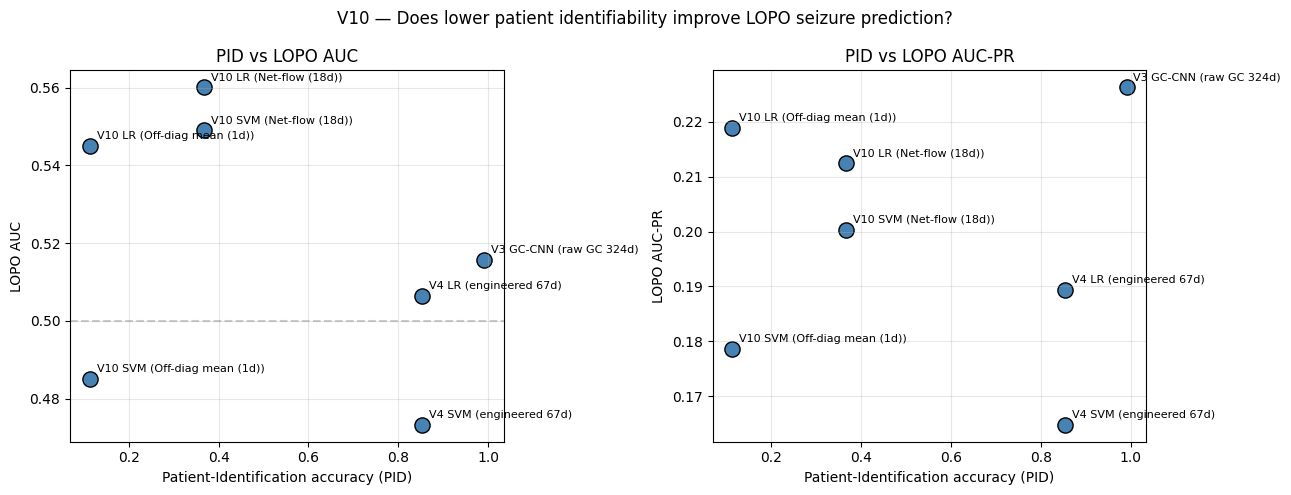

Saved v10_pid_vs_lopo.png


In [9]:
# Cell 8 — Scatter: PID vs LOPO AUC (and AUC-PR)
pid_values = {
    'V10 LR (Net-flow (18d))':       0.367,
    'V10 SVM (Net-flow (18d))':      0.367,
    'V10 LR (Off-diag mean (1d))':   0.113,
    'V10 SVM (Off-diag mean (1d))':  0.113,
    'V4 LR (engineered 67d)':        0.854,
    'V4 SVM (engineered 67d)':       0.854,
    'V3 GC-CNN (raw GC 324d)':       0.991,
}

points = []
for (rep_key, name), rows in all_results.items():
    if not rows: continue
    df = pd.DataFrame(rows)
    rep_label = REPRESENTATIONS[rep_key][0]
    label = f'V10 {name} ({rep_label})'
    points.append((pid_values.get(label, 0.5), df['auc'].mean(),
                   df['auc_pr'].mean(), label))

for blbl, key in [
    ('V4 LR (engineered 67d)',  'lopo_v4_LR.csv'),
    ('V4 SVM (engineered 67d)', 'lopo_v4_SVM.csv'),
    ('V3 GC-CNN (raw GC 324d)', 'lopo_v3_window.csv'),
]:
    df = _load_lopo_csv(Path(RESULTS_DIR) / key)
    if df is not None and not df.empty:
        points.append((pid_values[blbl], df['auc'].mean(),
                       df['auc_pr'].mean(), blbl))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, ycol, ylabel in zip(axes, [1, 2], ['LOPO AUC', 'LOPO AUC-PR']):
    xs = [p[0] for p in points]
    ys = [p[ycol] for p in points]
    labels = [p[3] for p in points]
    ax.scatter(xs, ys, s=120, c='steelblue', edgecolors='k')
    for x, y, l in zip(xs, ys, labels):
        ax.annotate(l, (x, y), fontsize=8, xytext=(5, 5), textcoords='offset points')
    ax.set_xlabel('Patient-Identification accuracy (PID)')
    ax.set_ylabel(ylabel)
    if ycol == 1:
        ax.axhline(0.5, ls='--', c='gray', alpha=0.4)
    ax.grid(alpha=0.3)
    ax.set_title(f'PID vs {ylabel}')

plt.suptitle('V10 — Does lower patient identifiability improve LOPO seizure prediction?', fontsize=12)
plt.tight_layout()
out = Path(RESULTS_DIR) / 'v10_pid_vs_lopo.png'
plt.savefig(out, dpi=130, bbox_inches='tight')
plt.show()
print(f'Saved {out.name}')


## 8 · Statistical test — V10 vs V4

Paired Wilcoxon signed-rank test on per-patient AUC-PR.


In [10]:
# Cell 9 — Wilcoxon V10 vs V4 (paired)
v4_lr = _load_lopo_csv(Path(RESULTS_DIR) / 'lopo_v4_LR.csv')
v4_svm = _load_lopo_csv(Path(RESULTS_DIR) / 'lopo_v4_SVM.csv')

def paired_test(df_v10, df_baseline, metric='auc_pr'):
    if df_v10 is None or df_baseline is None:
        return None
    m = df_v10.merge(df_baseline, on='patient', suffixes=('_v10', '_v4'))
    if len(m) < 5:
        return None
    diff = m[f'{metric}_v10'] - m[f'{metric}_v4']
    try:
        stat, pval = wilcoxon(diff)
    except ValueError:
        return None
    return dict(n=len(m), mean_diff=diff.mean(),
                median_diff=diff.median(), p=pval)

print('Wilcoxon V10 (paired vs V4) for AUC-PR:')
for (rep_key, name), rows in all_results.items():
    if not rows: continue
    df = pd.DataFrame(rows)
    rep_label = REPRESENTATIONS[rep_key][0]
    for baseline_label, baseline_df in [('V4 LR', v4_lr), ('V4 SVM', v4_svm)]:
        result = paired_test(df, baseline_df, 'auc_pr')
        if result:
            print(f'  V10 {name} ({rep_label}) vs {baseline_label}: '
                  f'n={result["n"]}, mean_diff={result["mean_diff"]:+.4f}, '
                  f'p={result["p"]:.4f}')


Wilcoxon V10 (paired vs V4) for AUC-PR:
  V10 LR (Net-flow (18d)) vs V4 LR: n=21, mean_diff=+0.0171, p=0.3205
  V10 LR (Net-flow (18d)) vs V4 SVM: n=21, mean_diff=+0.0418, p=0.0016
  V10 SVM (Net-flow (18d)) vs V4 LR: n=21, mean_diff=+0.0049, p=0.7593
  V10 SVM (Net-flow (18d)) vs V4 SVM: n=21, mean_diff=+0.0296, p=0.0216
  V10 LR (Off-diag mean (1d)) vs V4 LR: n=21, mean_diff=+0.0235, p=0.9187
  V10 LR (Off-diag mean (1d)) vs V4 SVM: n=21, mean_diff=+0.0482, p=0.0701
  V10 SVM (Off-diag mean (1d)) vs V4 LR: n=21, mean_diff=-0.0169, p=0.1193
  V10 SVM (Off-diag mean (1d)) vs V4 SVM: n=21, mean_diff=+0.0078, p=0.8117


## 9 · Final summary

What this notebook tests and how it relates to the thesis.


In [11]:
# Cell 10 — Summary printout
print('='*68)
print('V10 — Low-PID Feature Subsets — Summary')
print('='*68)
print(f'\nPatients: {len(patient_ids)}')
print(f'Total preictal:    {sum((y==1).sum() for _,(_,y) in patient_data.items()):,}')
print(f'Total interictal:  {sum((y==0).sum() for _,(_,y) in patient_data.items()):,}')
print()
print('Representations tested:')
for key, (label, _) in REPRESENTATIONS.items():
    pid = {'netflow': '36.7%', 'offdiag_mean': '11.3%'}[key]
    print(f'  - {label:25s}  PID={pid}')
print()
print('Models: LR, SVM (same as V4 winners)')
print()
print('Interpretation:')
print('  - If LOW-PID features IMPROVE LOPO AUC vs V4 -> patient identity was')
print('    the dominant confound (supports RQ2 mechanism).')
print('  - If LOW-PID features DEGRADE LOPO AUC -> preictal signal lives in')
print('    the patient-specific dimensions; cannot be cleanly separated.')
print()
print('Outputs:')
print('  - lopo_v10_{netflow,offdiag_mean}_{LR,SVM}.csv')
print('  - lopo_v10_summary.csv')
print('  - lopo_v10_vs_higher_pid.csv')
print('  - v10_pid_vs_lopo.png')


V10 — Low-PID Feature Subsets — Summary

Patients: 21
Total preictal:    10,908
Total interictal:  53,987

Representations tested:
  - Net-flow (18d)             PID=36.7%
  - Off-diag mean (1d)         PID=11.3%

Models: LR, SVM (same as V4 winners)

Interpretation:
  - If LOW-PID features IMPROVE LOPO AUC vs V4 -> patient identity was
    the dominant confound (supports RQ2 mechanism).
  - If LOW-PID features DEGRADE LOPO AUC -> preictal signal lives in
    the patient-specific dimensions; cannot be cleanly separated.

Outputs:
  - lopo_v10_{netflow,offdiag_mean}_{LR,SVM}.csv
  - lopo_v10_summary.csv
  - lopo_v10_vs_higher_pid.csv
  - v10_pid_vs_lopo.png
